# Experiment 4.1: LightGBM Hyperparameter Tuning & Imbalance Handling
In this notebook, we explore **LightGBM** and systematically test various imbalance handling techniques using **Optuna**.

### Why LightGBM?
LightGBM is a powerful Gradient Boosting framework that uses tree-based learning algorithms.
- **Speed & Memory**: Optimized for fast training and low memory usage through histogram-based learning.
- **Leaf-wise Growth**: It grows trees leaf-wise (best-first) rather than level-wise, which often leads to lower loss and better accuracy.
- **Sparse Feature Support**: Highly efficient with sparse data like TF-IDF vectors.

### Imbalance Handling Strategy
We will evaluate four popular oversampling techniques from the `imbalanced-learn` library:
1. **SMOTE** (Synthetic Minority Over-sampling Technique)
2. **SMOTETomek** (SMOTE + Tomek Links for cleaning)
3. **Borderline-SMOTE** (Focuses on minority samples near the boundary)
4. **ADASYN** (Adaptive Synthetic sampling)

### Setup:
- **Features**: TF-IDF (2500 features) + 3 Custom numeric features.
- **Scaling**: `RobustScaler`.
- **Optimization**: Optuna search for both model hyperparameters and the best imbalance strategy.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import os
import tempfile
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                              recall_score, classification_report, confusion_matrix, make_scorer)
from scipy.sparse import hstack
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set MLflow tracking
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("LightGBM Hyperparameter Tuning-2")

2026/04/14 14:53:11 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM Hyperparameter Tuning-2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/20', creation_time=1776158591108, experiment_id='20', last_update_time=1776158591108, lifecycle_stage='active', name='LightGBM Hyperparameter Tuning-2', tags={}, workspace='default'>

In [3]:
# Load and preprocess
data = pd.read_csv(r'../data/processed/dataset.csv')
data = data.dropna(subset=['text_processed', 'sentiment']).drop_duplicates()

# We keep the raw features to avoid leakage during CV
X = data[['text_processed', 'char_count', 'word_count', 'avg_word_len']]
y = data['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ── Industrial Best Practice: Preprocessing Pipeline ────────────────────────
# We define the ColumnTransformer here, but it will be FITTED inside the CV loop.
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=2500, ngram_range=(1,1)), 'text_processed'),
    ('scaler', RobustScaler(), ['char_count', 'word_count', 'avg_word_len'])
])

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Model Hyperparameters
    lgbm_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 1.0),
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }

    # Imbalance Strategy Choice
    resampler_name = trial.suggest_categorical('resampler', ['none', 'smote', 'smotetomek', 'borderline', 'adasyn'])
    
    if resampler_name == 'none':
        resampler = None
    elif resampler_name == 'smote':
        resampler = SMOTE(random_state=42)
    elif resampler_name == 'smotetomek':
        resampler = SMOTETomek(random_state=42)
    elif resampler_name == 'borderline':
        resampler = BorderlineSMOTE(random_state=42)
    elif resampler_name == 'adasyn':
        resampler = ADASYN(random_state=42)

    # ── Full Leak-Proof Pipeline ─────────────────────────────────────────────
    # Including preprocessor in the pipeline ensures Tfidf and Scaler are only
    # fitted on the training folds of the CV, avoiding data leakage.
    steps = [('preprocessor', preprocessor)]
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('classifier', LGBMClassifier(**lgbm_params)))
    
    model_pipeline = Pipeline(steps)

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    def bottleneck_objective_scorer(estimator, X, y):
        y_pred = estimator.predict(X)
        neutral_label_idx = np.where(le.classes_ == 0)[0][0]
        precisions = precision_score(y, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
        prec_neutral = precisions[neutral_label_idx]
        f1_macro = f1_score(y, y_pred, average='macro')
        return (0.70 * prec_neutral) + (0.30 * f1_macro)

    with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}"):
        # Pass raw X_train, y_train. Pipeline handles fitting/transforming internally.
        cv_scores = cross_val_score(
            model_pipeline, X_train, y_train, 
            cv=skf, scoring=bottleneck_objective_scorer
        )
        avg_combined_score = float(np.mean(cv_scores))

        mlflow.log_params(lgbm_params)
        mlflow.log_param("resampler", resampler_name)
        mlflow.log_metrics({
            "cv_avg_bottleneck_score": avg_combined_score,
            "cv_std_dev": float(np.std(cv_scores)),
            "trial_number": trial.number,
        })

    return avg_combined_score

# Run Study
with mlflow.start_run(run_name="Optuna_LGBM_CV_Search"):
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50)

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_cv_bottleneck_score", study.best_value)

    print(f"Best CV Score: {study.best_value:.4f}")
    print(f"Best Params: {study.best_params}")

c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run Trial_0 at: http://localhost:5000/#/experiments/20/runs/8a997b1216cc45c98b900f33aa697249
🧪 View experiment at: http://localhost:5000/#/experiments/20


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run Trial_1 at: http://localhost:5000/#/experiments/20/runs/303f1338a68448cbbb786215dcf9489c
🧪 View experiment at: http://localhost:5000/#/experiments/20


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

🏃 View run Trial_47 at: http://localhost:5000/#/experiments/20/runs/29f9a06afc254c55950b77260732693f
🧪 View experiment at: http://localhost:5000/#/experiments/20


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run Trial_48 at: http://localhost:5000/#/experiments/20/runs/91509afba015407ebdf9f1e8e7dd47b3
🧪 View experiment at: http://localhost:5000/#/experiments/20


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🏃 View run Trial_49 at: http://localhost:5000/#/experiments/20/runs/8d67e98c5a824df996708aee99ea43f8
🧪 View experiment at: http://localhost:5000/#/experiments/20
Best CV Score: 0.7992
Best Params: {'n_estimators': 1240, 'learning_rate': 0.03323249830949845, 'num_leaves': 147, 'max_depth': 13, 'min_child_samples': 5, 'subsample': 0.9369645117719385, 'colsample_bytree': 0.6612183865216443, 'reg_alpha': 1.3237755854340723e-08, 'reg_lambda': 3.861791897485102e-08, 'min_split_gain': 0.6329924721339453, 'resampler': 'none'}
🏃 View run Optuna_LGBM_CV_Search at: http://localhost:5000/#/experiments/20/runs/7b835f69bbfe4cc384b8c29cd279024f
🧪 View experiment at: http://localhost:5000/#/experiments/20


c:\data-science-projects\major-projects\youtube_comment_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


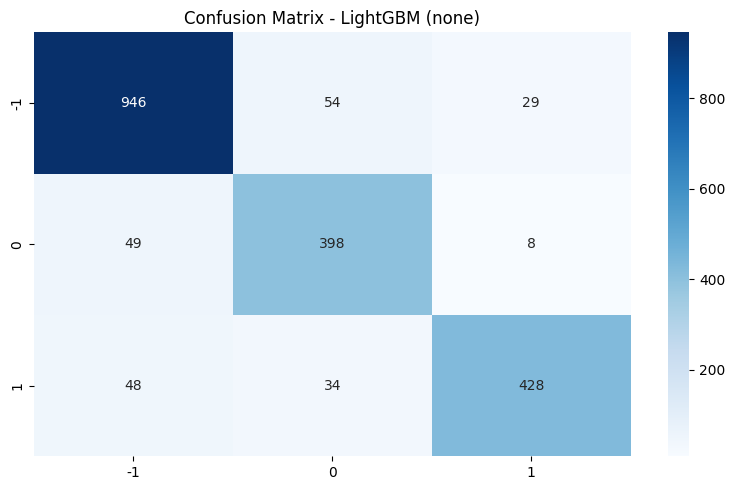

🏃 View run LGBM_Optimized_Final at: http://localhost:5000/#/experiments/20/runs/5aefa38d7b6a4717864a70a43a97a3f4
🧪 View experiment at: http://localhost:5000/#/experiments/20


In [5]:
best_params = study.best_params.copy()
resampler_name = best_params.pop('resampler')
best_params['random_state'] = 42
best_params['verbosity'] = -1

# Re-create the best resampler
if resampler_name == 'none':
    resampler = None
elif resampler_name == 'smote':
    resampler = SMOTE(random_state=42)
elif resampler_name == 'smotetomek':
    resampler = SMOTETomek(random_state=42)
elif resampler_name == 'borderline':
    resampler = BorderlineSMOTE(random_state=42)
elif resampler_name == 'adasyn':
    resampler = ADASYN(random_state=42)

with mlflow.start_run(run_name="LGBM_Optimized_Final"):
    # Re-build final pipeline
    steps = [('preprocessor', preprocessor)]
    if resampler:
        steps.append(('resampler', resampler))
    steps.append(('classifier', LGBMClassifier(**best_params)))
    
    final_pipeline = Pipeline(steps)
    final_pipeline.fit(X_train, y_train)
    y_pred = final_pipeline.predict(X_test)
    
    # ── Log Parameters ────────────────────────────────────────────────────────
    full_params = {
        "test_size": 0.2,
        "stratify": True,
        "representation": "TFIDF_2500",
        "scaler": "RobustScaler",
        "model_name": "LightGBM_Optimized",
        "resampler": resampler_name,
        "leak_proof": True
    }
    full_params.update(best_params)
    mlflow.log_params(full_params)

    # ── Log Metrics ───────────────────────────────────────────────────────────
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": report_dict['weighted avg']['f1-score'],
        "f1_macro": report_dict['macro avg']['f1-score'],
        "precision_macro": report_dict['macro avg']['precision'],
        "recall_macro": report_dict['macro avg']['recall']
    }
    for i, label in enumerate(le.classes_):
        metrics[f"f1_class_{label}"] = report_dict[str(i)]['f1-score']
        metrics[f"precision_class_{label}"] = report_dict[str(i)]['precision']
        metrics[f"recall_class_{label}"] = report_dict[str(i)]['recall']
    mlflow.log_metrics(metrics)

    # ── Log Artifacts ─────────────────────────────────────────────────────────
    report_str = classification_report(y_test, y_pred, target_names=le.classes_.astype(str))
    with tempfile.TemporaryDirectory() as tmp_dir:
        report_path = os.path.join(tmp_dir, "classification_report.txt")
        with open(report_path, "w") as f:
            f.write(report_str)
        mlflow.log_artifact(report_path)

        plt.figure(figsize=(8, 5))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_)
        plt.title(f'Confusion Matrix - LightGBM ({resampler_name})')
        plt.tight_layout()
        cm_path = os.path.join(tmp_dir, "confusion_matrix.png")
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.show()
        plt.close()

#### Conclusion: 
we are using lightGBM model since lightgbm is giving better results than logistic regression.

model parms -> best
config = {
    "test_size": 0.2,
    "stratify": True,
    "representation": "TFIDF_2500",
    "scaler": "RobustScaler",
    "model_name": "LightGBM_Optimized",
    "resampler": "none",
    "leak_proof": True,
    "n_estimators": 1240,
    "learning_rate": 0.03323249830949845,
    "num_leaves": 147,
    "max_depth": 13,
    "min_child_samples": 5,
    "subsample": 0.9369645117719385,
    "colsample_bytree": 0.6612183865216443,
    "reg_alpha": 1.3237755854340723e-08,
    "reg_lambda": 3.861791897485102e-08,
    "min_split_gain": 0.6329924721339453,
    "random_state": 42,
    "verbosity": -1
}